In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
import yfinance as yf
import backtrader as bt
import pandas as pd

# Strat Backtesting

In [2]:
tickers = [
    "AAPL",
    "MSFT",
    "AMZN",
    "GOOGL",
    "XOM",
    "CVX",
    "JPM",
    "BAC",
    "TSLA",
    "AMD",
    "UNH",
    "JNJ"   
]

In [3]:
datas = [yf.download(i, start='2003-01-01', end='2023-01-01') for i in tickers]
for data in datas:
    data.columns = [col[0] for col in data.columns.values]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [155]:
class EqualWeightBuyHold(bt.Strategy):

    def __init__(self):
        self.bought = False

    def notify_order(self, order):

        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:

            side = "BUY" if order.isbuy() else "SELL"

            print(
                f"{self.datetime.date(0)} "
                f"{side} {order.data._name} "
                f"@ {order.executed.price:.2f}"
            )

    def next(self):

        # Only execute once (first bar)
        if self.bought:
            return

        n = len(self.datas)

        cash = self.broker.getcash()
        allocation = cash / n

        for d in self.datas:

            price = d.close[0]

            size = int(allocation / price)

            if size > 0:
                self.buy(data=d, size=size)

        self.bought = True

In [156]:
cerebro = bt.Cerebro()
cerebro.broker.setcash(100000)
cerebro.broker.setcommission(commission=0.001)
cerebro.addstrategy(EqualWeightBuyHold)
for data in datas:
    data_feed = bt.feeds.PandasData(dataname=data,
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        openinterest=None)
    cerebro.adddata(data_feed)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
res = cerebro.run()
strat_buyhold = res[0]

2010-06-30 BUY  @ 7.68
2010-06-30 BUY  @ 17.50
2010-06-30 BUY  @ 5.43
2010-06-30 BUY  @ 11.29
2010-06-30 BUY  @ 31.40
2010-06-30 BUY  @ 35.95
2010-06-30 BUY  @ 24.46
2010-06-30 BUY  @ 11.29
2010-06-30 BUY  @ 1.72
2010-06-30 BUY  @ 7.58
2010-06-30 BUY  @ 22.18


In [157]:
print(strat_buyhold.analyzers.sharpe.get_analysis())
print(strat_buyhold.analyzers.drawdown.get_analysis())
print(strat_buyhold.analyzers.returns.get_analysis())
print(strat_buyhold.analyzers.trades.get_analysis())

OrderedDict([('sharperatio', 0.4453835348178731)])
AutoOrderedDict([('len', 250), ('drawdown', 54.78148198219957), ('moneydown', 1793045.1302528381), ('max', AutoOrderedDict([('len', 268), ('drawdown', 57.19951484184305), ('moneydown', 1872189.430240631)]))])
OrderedDict([('rtot', 2.694654934331166), ('ravg', 0.000535184694008176), ('rnorm', 0.14438404797195992), ('rnorm100', 14.438404797195991)])
AutoOrderedDict([('total', AutoOrderedDict([('total', 11), ('open', 11)]))])


In [158]:
ewbh_prof = cerebro.broker.getvalue() - 100000
ewbh_prof

1380041.0758404206

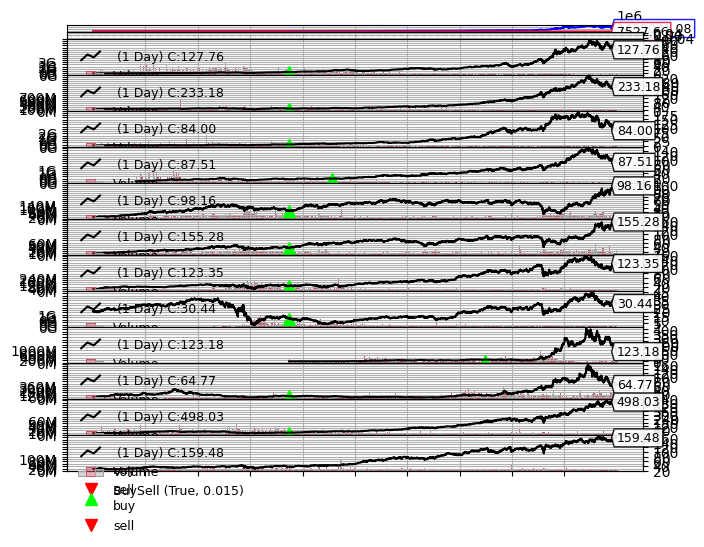

[[<Figure size 640x480 with 26 Axes>]]

In [159]:
cerebro.plot(iplot=False)

In [160]:
class SMACrossover(bt.Strategy):

    params = dict(
        fast=20,
        slow=50
    )

    def __init__(self):

        self.sma_fast = {}
        self.sma_slow = {}

        for d in self.datas:

            self.sma_fast[d] = bt.ind.SMA(
                d.close,
                period=self.p.fast
            )

            self.sma_slow[d] = bt.ind.SMA(
                d.close,
                period=self.p.slow
            )

    def notify_order(self, order):

        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:

            side = "BUY" if order.isbuy() else "SELL"

            print(
                f"{self.datetime.date(0)} "
                f"{side} {order.data._name} "
                f"@ {order.executed.price:.2f}"
            )

    def next(self):

        for d in self.datas:

            pos = self.getposition(d)

            fast = self.sma_fast[d][0]
            slow = self.sma_slow[d][0]

            # ENTER
            if pos.size == 0:

                if fast > slow:
                    self.buy(data=d, size=1)

            # EXIT
            else:

                if fast < slow:
                    self.close(data=d)
    params = dict(
        sma_fast=20,
        sma_slow=50,

        market_fast=50,
        market_slow=200,

        atr_period=14,

        momentum_lookback=60,

        risk_per_trade=0.01,
        atr_stop_multiple=2.0,

        max_positions=10,
    )

    def __init__(self):

        # First data feed must be SPY
        self.market = self.datas[0]

        self.market_sma_fast = bt.indicators.SMA(
            self.market.close,
            period=self.p.market_fast
        )

        self.market_sma_slow = bt.indicators.SMA(
            self.market.close,
            period=self.p.market_slow
        )

        self.sma_fast = {}
        self.sma_slow = {}
        self.atr = {}

        self.trailing_stop = {}

        for d in self.datas[1:]:

            self.sma_fast[d] = bt.indicators.SMA(
                d.close,
                period=self.p.sma_fast
            )

            self.sma_slow[d] = bt.indicators.SMA(
                d.close,
                period=self.p.sma_slow
            )

            self.atr[d] = bt.indicators.ATR(
                d,
                period=self.p.atr_period
            )

    def market_bull(self):

        return (
            self.market_sma_fast[0]
            >
            self.market_sma_slow[0]
        )

    def momentum_score(self, d):

        if len(d) < self.p.momentum_lookback:
            return float("-inf")

        return (
            d.close[0]
            /
            d.close[-self.p.momentum_lookback]
            - 1.0
        )

    def calc_position_size(self, d):

        atr = self.atr[d][0]

        if atr <= 0:
            return 0

        portfolio_value = self.broker.getvalue()

        dollar_risk = (
            portfolio_value *
            self.p.risk_per_trade
        )

        stop_distance = (
            self.p.atr_stop_multiple *
            atr
        )

        shares = int(
            dollar_risk /
            stop_distance
        )

        cash_limited = int(
            self.broker.getcash() /
            d.close[0]
        )

        return max(
            min(shares, cash_limited),
            0
        )

    def notify_order(self, order):

        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:

            side = (
                "BUY"
                if order.isbuy()
                else "SELL"
            )

            print(
                f"{self.datetime.date()} "
                f"{side} "
                f"{order.data._name} "
                f"@ {order.executed.price:.2f}"
            )

        elif order.status in [
            order.Canceled,
            order.Margin,
            order.Rejected,
        ]:

            print(
                f"{self.datetime.date()} "
                f"FAILED "
                f"{order.data._name} "
                f"{order.getstatusname()}"
            )

    def next(self):

        if not self.market_bull():
            return

        # =====================
        # Manage existing positions
        # =====================

        for d in self.datas[1:]:

            pos = self.getposition(d)

            if pos.size == 0:
                continue

            atr = self.atr[d][0]

            new_stop = (
                d.close[0]
                -
                self.p.atr_stop_multiple *
                atr
            )

            old_stop = self.trailing_stop.get(
                d,
                new_stop
            )

            self.trailing_stop[d] = max(
                old_stop,
                new_stop
            )

            if d.close[0] < self.trailing_stop[d]:

                self.close(data=d)

        # =====================
        # Find new candidates
        # =====================

        open_positions = sum(
            self.getposition(d).size > 0
            for d in self.datas[1:]
        )

        slots = (
            self.p.max_positions
            - open_positions
        )

        if slots <= 0:
            return

        candidates = []

        for d in self.datas[1:]:

            if self.getposition(d).size != 0:
                continue

            if (
                self.sma_fast[d][0]
                <=
                self.sma_slow[d][0]
            ):
                continue

            score = self.momentum_score(d)

            candidates.append(
                (score, d)
            )

        candidates.sort(
            key=lambda x: x[0],
            reverse=True
        )

        # =====================
        # Buy strongest names
        # =====================

        for score, d in candidates[:slots]:

            size = self.calc_position_size(d)

            if size <= 0:
                continue

            self.buy(
                data=d,
                size=size
            )

            self.trailing_stop[d] = (
                d.close[0]
                -
                self.p.atr_stop_multiple *
                self.atr[d][0]
            )

    def stop(self):

        print(
            "\nFinal Value:",
            round(
                self.broker.getvalue(),
                2
            )
        )

In [161]:
cerebro = bt.Cerebro()
cerebro.broker.setcash(100000)
cerebro.broker.setcommission(
    commission=0.001
)
cerebro.addstrategy(
    SMACrossover
)
for data in datas:
    data_feed = bt.feeds.PandasData(dataname=data,
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        openinterest=None)
    cerebro.adddata(data_feed)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
res = cerebro.run()
strat = res[0]

2010-09-09 BUY  @ 7.02
2010-09-09 BUY  @ 26.53
2010-09-09 BUY  @ 41.44
2010-09-09 FAILED  Margin
2010-09-10 FAILED  Margin
2010-09-13 FAILED  Margin
2010-09-13 FAILED  Margin
2010-09-14 FAILED  Margin
2010-09-14 FAILED  Margin
2010-09-15 FAILED  Margin
2010-09-15 BUY  @ 33.52
2010-09-16 FAILED  Margin
2010-09-16 BUY  @ 38.58
2010-09-17 BUY  @ 1.40
2010-10-07 SELL  @ 26.86
2010-10-08 FAILED  Margin
2010-10-08 FAILED  Margin
2010-10-08 FAILED  Margin
2010-10-08 FAILED  Margin
2010-10-08 FAILED  Margin
2010-10-11 FAILED  Margin
2010-10-11 FAILED  Margin
2010-10-11 FAILED  Margin
2010-10-11 FAILED  Margin
2010-10-11 FAILED  Margin
2010-10-12 FAILED  Margin
2010-10-12 FAILED  Margin
2010-10-12 FAILED  Margin
2010-10-12 FAILED  Margin
2010-10-12 SELL  @ 7.63
2010-10-12 BUY  @ 13.41
2010-10-13 FAILED  Margin
2010-10-13 FAILED  Margin
2010-10-13 FAILED  Margin
2010-10-13 FAILED  Margin
2010-10-13 BUY  @ 7.83
2010-10-14 FAILED  Margin
2010-10-14 FAILED  Margin
2010-10-14 FAILED  Margin
2010-10-

In [162]:
print(strat.analyzers.sharpe.get_analysis())
print(strat.analyzers.drawdown.get_analysis())
print(strat.analyzers.returns.get_analysis())
print(strat.analyzers.trades.get_analysis())

OrderedDict([('sharperatio', 0.5322532335330536)])
AutoOrderedDict([('len', 177), ('drawdown', 6.42753690268212), ('moneydown', 56558.89289274113), ('max', AutoOrderedDict([('len', 433), ('drawdown', 23.95050943067609), ('moneydown', 132652.15710570675)]))])
OrderedDict([('rtot', 2.1082570023816456), ('ravg', 0.00041872035797053535), ('rnorm', 0.11128558542019819), ('rnorm100', 11.12855854201982)])
AutoOrderedDict([('total', AutoOrderedDict([('total', 843), ('open', 2), ('closed', 841)])), ('streak', AutoOrderedDict([('won', AutoOrderedDict([('current', 0), ('longest', 10)])), ('lost', AutoOrderedDict([('current', 3), ('longest', 15)]))])), ('pnl', AutoOrderedDict([('gross', AutoOrderedDict([('total', 731256.4337416217), ('average', 869.5082446392647)])), ('net', AutoOrderedDict([('total', 657096.125155617), ('average', 781.3271404941938)]))])), ('won', AutoOrderedDict([('total', 369), ('pnl', AutoOrderedDict([('total', 1546217.1697137204), ('average', 4190.29043282851), ('max', 76423.

In [163]:
smac_prof = cerebro.broker.getvalue() - 100000
smac_prof

723387.7141681986

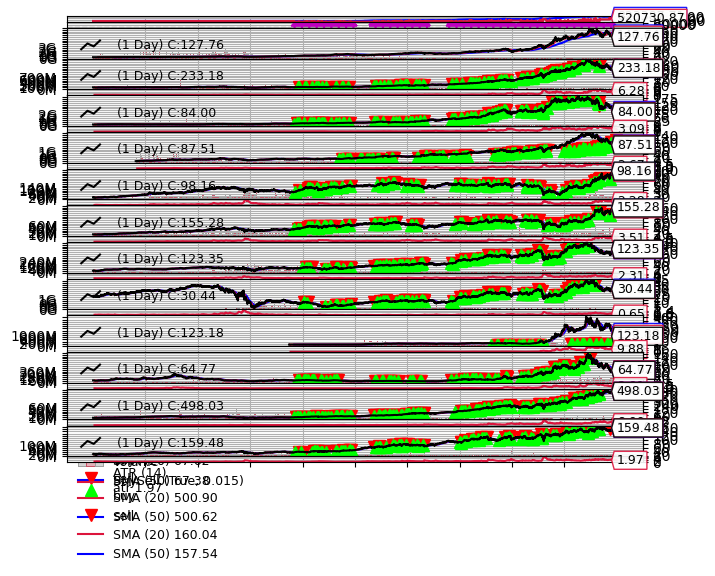

[[<Figure size 640x480 with 37 Axes>]]

In [164]:
cerebro.plot(iplot=False)

In [165]:
class CrossSectionalMomentum(bt.Strategy):

    params = dict(
        lookback=60,
        rebalance_days=21,
        top_n=3
    )

    def __init__(self):

        self.day_count = 0

        self.momentum = {}

        for d in self.datas:

            self.momentum[d] = d.close / d.close(-self.p.lookback) - 1

    def notify_order(self, order):

        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:

            side = "BUY" if order.isbuy() else "SELL"

            print(
                f"{self.datetime.date(0)} "
                f"{side} {order.data._name} "
                f"@ {order.executed.price:.2f}"
            )

    def next(self):

        self.day_count += 1

        # Only rebalance monthly-ish
        if self.day_count % self.p.rebalance_days != 0:
            return

        # -------------------------
        # Calculate momentum scores
        # -------------------------
        scores = []

        for d in self.datas:

            pos = self.getposition(d)

            if len(d) < self.p.lookback:
                continue

            score = (
                d.close[0] /
                d.close[-self.p.lookback]
                - 1
            )

            scores.append((score, d))

        # Rank descending
        scores.sort(reverse=True, key=lambda x: x[0])

        top = scores[:self.p.top_n]

        selected = set(d for _, d in top)

        # -------------------------
        # Exit losers / non-selected
        # -------------------------
        for d in self.datas:

            pos = self.getposition(d)

            if pos.size > 0 and d not in selected:
                self.close(data=d)

        # -------------------------
        # Enter winners
        # -------------------------
        cash_per_name = self.broker.getcash() / max(len(top), 1)

        for score, d in top:

            pos = self.getposition(d)

            if pos.size > 0:
                continue

            size = int(cash_per_name / d.close[0])

            if size > 0:
                self.buy(data=d, size=size)

In [166]:
cerebro = bt.Cerebro()
cerebro.broker.setcash(100000)
cerebro.broker.setcommission(
    commission=0.001
)
cerebro.addstrategy(
    CrossSectionalMomentum
)
for data in datas:
    data_feed = bt.feeds.PandasData(dataname=data,
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        openinterest=None)
    cerebro.adddata(data_feed)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
res = cerebro.run()
strat = res[0]

2010-10-22 BUY  @ 8.12
2010-10-22 BUY  @ 15.19
2010-11-22 BUY  @ 2.10
2010-12-22 SELL  @ 9.25
2010-12-22 SELL  @ 14.99
2010-12-22 BUY  @ 40.49
2010-12-22 BUY  @ 8.17
2011-01-24 SELL  @ 1.57
2011-01-24 SELL  @ 7.53
2011-01-24 BUY  @ 11.02
2011-01-24 BUY  @ 29.98
2011-02-23 SELL  @ 30.53
2011-02-23 BUY  @ 54.34
2011-03-24 SELL  @ 10.50
2011-03-24 BUY  @ 33.98
2011-04-25 SELL  @ 48.16
2011-04-25 BUY  @ 8.67
2011-05-24 SELL  @ 55.48
2011-05-24 SELL  @ 8.55
2011-05-24 BUY  @ 1.80
2011-05-24 BUY  @ 9.85
2011-07-25 SELL  @ 1.93
2011-07-25 SELL  @ 41.37
2011-07-25 BUY  @ 15.22
2011-07-25 BUY  @ 11.69
2011-08-23 SELL  @ 8.95
2011-08-23 SELL  @ 12.50
2011-08-23 BUY  @ 18.60
2011-08-23 BUY  @ 41.37
2011-09-22 SELL  @ 19.58
2011-09-22 SELL  @ 40.84
2011-09-22 BUY  @ 11.24
2011-09-22 BUY  @ 13.06
2011-10-21 SELL  @ 14.63
2011-10-21 BUY  @ 21.01
2011-11-21 SELL  @ 11.09
2011-11-21 SELL  @ 19.68
2011-11-21 SELL  @ 9.66
2011-11-21 BUY  @ 2.16
2011-11-21 BUY  @ 14.59
2011-11-21 BUY  @ 43.49
2011-12-21 

In [167]:
print(strat.analyzers.sharpe.get_analysis())
print(strat.analyzers.drawdown.get_analysis())
print(strat.analyzers.returns.get_analysis())
print(strat.analyzers.trades.get_analysis())

OrderedDict([('sharperatio', 0.5814539501566365)])
AutoOrderedDict([('len', 142), ('drawdown', 7.601752843442121), ('moneydown', 72170.56868847727), ('max', AutoOrderedDict([('len', 519), ('drawdown', 33.5001251767122), ('moneydown', 179314.2654908864)]))])
OrderedDict([('rtot', 2.171591291216897), ('ravg', 0.0004312991640947164), ('rnorm', 0.1148137932005112), ('rnorm100', 11.48137932005112)])
AutoOrderedDict([('total', AutoOrderedDict([('total', 185), ('open', 3), ('closed', 182)])), ('streak', AutoOrderedDict([('won', AutoOrderedDict([('current', 0), ('longest', 6)])), ('lost', AutoOrderedDict([('current', 5), ('longest', 5)]))])), ('pnl', AutoOrderedDict([('gross', AutoOrderedDict([('total', 781009.0221770089), ('average', 4291.258363609939)])), ('net', AutoOrderedDict([('total', 761895.5076445596), ('average', 4186.239052992086)]))])), ('won', AutoOrderedDict([('total', 101), ('pnl', AutoOrderedDict([('total', 1059359.9390246642), ('average', 10488.712267570932), ('max', 189607.53

In [168]:
csm_prof = cerebro.broker.getvalue() - 100000
csm_prof

777223.211599149

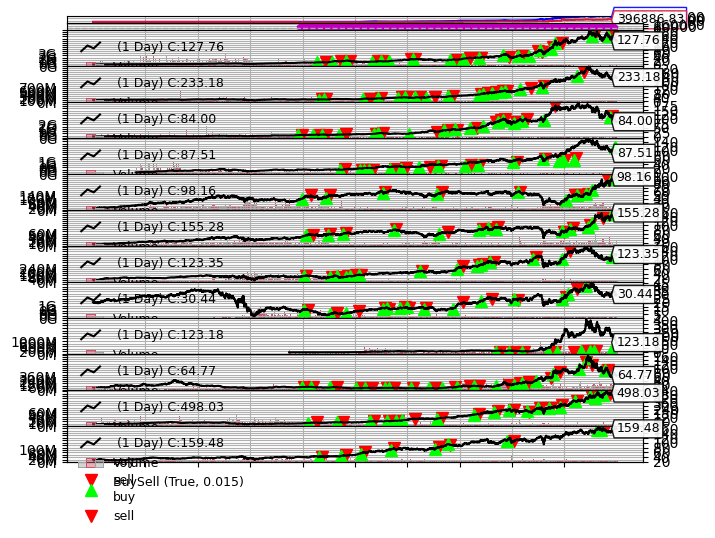

[[<Figure size 640x480 with 26 Axes>]]

In [169]:
cerebro.plot(iplot=False)

<BarContainer object of 3 artists>

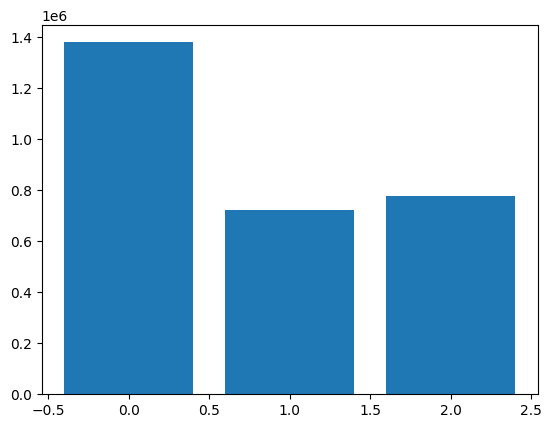

In [170]:
profs = np.array([ewbh_prof, smac_prof, csm_prof])
plt.bar(np.arange(len(profs)), profs)

In [171]:
profs[0]/profs[1:]

array([1.90774746, 1.77560456])

# Predicting/Understanding Slippage

## EM-HMM For Slippage Regimes

In [4]:
class MomentumWithSlippage(bt.Strategy):

    params = dict(
        lookback=60,
        rebalance_days=21,
        top_n=3
    )

    def __init__(self):

        self.day_count = 0
        self.order_map = {}

        self.slippage_log = []

    def notify_order(self, order):

        if order.status in [order.Submitted, order.Accepted]:
            return

        if order.status == order.Completed:

            d = order.data

            fill_price = order.executed.price

            # proxy "expected price"
            expected_price = d.open[0]  # simple & consistent

            slippage = (
                fill_price - expected_price
                if order.isbuy()
                else expected_price - fill_price
            )

            self.slippage_log.append({
                "date": self.datetime.date(0),
                "ticker": d._name,
                "side": "BUY" if order.isbuy() else "SELL",
                "fill_price": fill_price,
                "expected_price": expected_price,
                "slippage": slippage,
                "volume": d.volume[0],
                "close": d.close[0],
                "high": d.high[0],
                "low": d.low[0],
            })

    def next(self):

        self.day_count += 1

        if self.day_count % self.p.rebalance_days != 0:
            return

        scores = []

        for d in self.datas:

            if len(d) < self.p.lookback:
                continue

            momentum = (
                d.close[0] / d.close[-self.p.lookback] - 1
            )

            scores.append((momentum, d))

        scores.sort(reverse=True, key=lambda x: x[0])

        top = scores[:self.p.top_n]

        selected = set(d for _, d in top)

        # exit non-selected
        for d in self.datas:
            pos = self.getposition(d)
            if pos.size > 0 and d not in selected:
                self.close(data=d)

        # enter selected
        cash_per = self.broker.getcash() / max(len(top), 1)

        for score, d in top:

            if self.getposition(d).size > 0:
                continue

            size = int(cash_per / d.close[0])

            if size > 0:
                self.buy(data=d, size=size)

    def stop(self):

        self.slippage_df = pd.DataFrame(self.slippage_log)

        print("\nTotal trades:", len(self.slippage_log))
        print("Avg slippage:", self.slippage_df["slippage"].mean())

In [5]:
cerebro = bt.Cerebro()
cerebro.broker.setcash(100000)
cerebro.broker.set_coc(False)
cerebro.broker.setcommission(
    commission=0.001
)
cerebro.broker.set_slippage_perc(
    0.001,
    slip_open=True,
    slip_match=True
)
cerebro.addstrategy(
    MomentumWithSlippage
)
for data in datas:
    data_feed = bt.feeds.PandasData(dataname=data,
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        openinterest=None)
    cerebro.adddata(data_feed)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
res = cerebro.run()
strat = res[0]


Total trades: 347
Avg slippage: 0.06565993918377738


In [6]:
slip_data = strat.slippage_df

In [7]:
slip_data.head()

,date,ticker,side,fill_price,expected_price,slippage,volume,close,high,low
0,2010-07-29,,BUY,23.747174,23.723450,0.023723,5540300.0,23.684547,24.026899,23.373318
1,2010-07-29,,BUY,7.812269,7.804464,0.007804,643806800.0,7.726632,7.862539,7.666463
2,2010-08-27,,SELL,7.229655,7.236892,0.007237,548391200.0,7.233000,7.262636,7.051591
3,2010-08-27,,BUY,39.346430,39.307123,0.039307,8789500.0,39.860371,39.918887,38.796434
4,2010-08-27,,BUY,6.279273,6.273000,0.006273,101600000.0,6.332000,6.332000,6.112500


<Axes: >

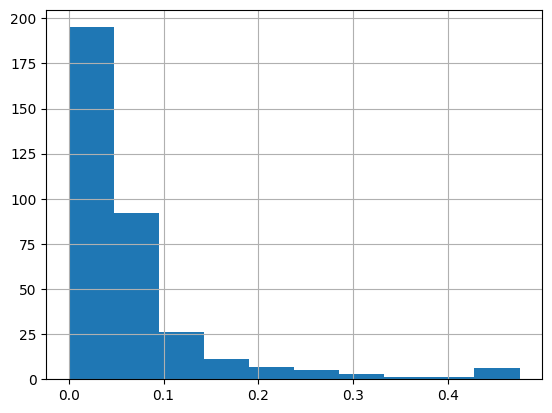

In [8]:
slip_data.slippage.hist()